# Compare results across hyperparameters
Collect performance information like F1 scores for a given model architecture while varying the hyperparameters in the objective function that weight the weak and self-supervised terms; plot performance several different ways in a heatmap format

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import genfromtxt
import os
import pandas as pd
import pickle
import seaborn as sns
import time

from daart.data import DataGenerator, compute_sequence_pad
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir
from daart.transforms import ZScore

from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams
from daart_utils.paths import data_path, results_path
# from daart_utils.plotting import plot_heatmaps

In [19]:
# save predicted states from models
save_states = True
# overwrite predicted states from models
overwrite_states = False

# 0 to compute metrics w/o using background timepoints, None to include all timepoints
background = 0

dataset = 'fly-5'
# dataset = 'ibl'
# dataset = 'mouse-oft-aligned'
# dataset = 'resident-intruder'
# dataset = 'calms21'

# input_types = ['features-posvel']
# input_types = ['features-simba']
input_types = ['markers']
# input_types = ['features-sturman']
# input_types = ['markers', 'features-simba', 'features-aligned'] #, 'features-simba']
# input_types = ['markers', 'features-simba', 'features-posvel', 'features-sturman']
# input_types = ['markers', 'features-simba', 'features-sturman']
# input_types = ['markers', 'features-simba', 'features-treba', 'features-treba-simba']
sequence_length = 2000
batch_size = 8
lambda_weak = 0
lambda_strong = 1
lambda_pred = 0
n_good_sessions_list = [1, 2, 3, 4, 5]
samples = [0, 1, 2, 3, 4]
# n_good_sessions_list = [5]
# samples = [0]
include_random_forest = True
include_xgboost = True

if dataset == 'fish':
    from daart_utils.session_ids.fish import SESS_IDS_TRAIN_10, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_10[0]
elif dataset == 'fly' or dataset == 'fly-4' or dataset == 'fly-5':
    from daart_utils.session_ids.fly import SESS_IDS_TRAIN_5, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_5[0]    
elif dataset == 'ibl':
    from daart_utils.session_ids.ibl import SESS_IDS_TRAIN_5, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_5[0]
elif dataset == 'mouse-oft' or dataset == 'mouse-oft-aligned' or dataset == 'mouse-oft-aligned-new':
    from daart_utils.session_ids.oft import SESS_IDS_TRAIN_10, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_10[0]
    sequence_length = 500
    n_good_sessions_list = [4, 6, 8, 10]
    samples = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
elif dataset == 'resident-intruder':
    from daart_utils.session_ids.resident_intruder import SESS_IDS_TRAIN_6, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_6[0]
    sequence_length = 1000
elif dataset == 'calms21':
    from daart_utils.session_ids.calms21 import SESS_IDS_TRAIN_10, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_10[0]
    sequence_length = 500
    n_good_sessions_list = [2, 4, 6, 8, 10]
    
# test datasets
sess_ids_test = SESS_IDS_TEST

expt_dir = get_expt_dir(os.path.join(results_path, dataset), sess_ids)
# expt_dir = '/media/mattw/behavior/results/daart/mouse-oft-aligned_s3/multi-0'

# fill out hparams
backbone = 'dtcn'
model_class = 'segmenter'
hparams = get_default_hparams(
    model_class=model_class, device='cuda', sequence_length=sequence_length, 
    batch_size=batch_size, backbone=backbone, n_lags=4, n_hid_layers=2)
hparams['sequence_pad'] = compute_sequence_pad(hparams)

tree_model_strs = []
tree_model_types = []
if include_random_forest:
    tree_model_strs.append('Random Forest')
    tree_model_types.append('random-forest')
if include_xgboost:
    tree_model_strs.append('XGBoost')
    tree_model_types.append('xgboost')
                    
model_types = [backbone]  # legacy, need to clean up
metrics_df = []
timing_dict = {d: [] for d in tree_model_types}
for input_type in input_types:
    input_type_trees = input_type
    hparams['input_type'] = input_type
    
    for sess_id_test in sess_ids_test:

        # initialize data handler; point to correct base path
        handler = DataHandler(sess_id_test, base_path=os.path.join(data_path, dataset))

        # build data generator: markers
        if input_type == 'markers':
            markers_file = handler.get_marker_filepath()
        else:
            markers_file = handler.get_feature_filepath(dirname=input_type)
        signals = ['markers']
        transforms = [ZScore()]
        paths = [markers_file]
        data_gen_test = DataGenerator(
            [sess_id_test], [signals], [transforms], [paths], device=hparams['device'], 
            batch_size=hparams['batch_size'], trial_splits=hparams['trial_splits'], 
            sequence_pad=hparams['sequence_pad'], sequence_length=hparams['sequence_length'],
            input_type=input_type)
        print('----------------------------')
        print(data_gen_test)
        print('----------------------------')
        print('\n')

        # build data generator: features (for random forest)
        if include_random_forest or include_xgboost:
            if input_type_trees == 'markers':
                markers_file = handler.get_marker_filepath()
            else:
                markers_file = handler.get_feature_filepath(dirname=input_type_trees)
            signals = ['markers']
            transforms = [ZScore()]
            paths = [markers_file]
            data_gen_test_trees = DataGenerator(
                [sess_id_test], [signals], [transforms], [paths], device='cpu', 
                batch_size=1, trial_splits=hparams['trial_splits'],
                sequence_pad=0, sequence_length=hparams['sequence_length'],
                input_type=input_type_trees)

        # load hand labels
        handler.load_hand_labels()
        states = np.argmax(handler.hand_labels.vals, axis=1)
        cutoff = int(np.floor(states.shape[0] / hparams['sequence_length'])) * hparams['sequence_length']
        states = states[:cutoff]
        label_names = handler.hand_labels.names
        if background is None:
            raise NotImplementedError
        n_classes = len(label_names) if background is None else len(label_names) - 1
        counts = np.zeros(len(label_names))
        counts_ = np.bincount(states)
        counts[:counts_.shape[0]] = counts_

        # -----------------------------------------
        # collect results
        # -----------------------------------------    
        for n_good_sessions in n_good_sessions_list:
            for sample in samples:

                tt_expt_dir = '%i-good_sample-%i_%s' % (n_good_sessions, sample, input_type)
                hparams['input_type'] = input_type
                hparams['model_class'] = model_class
                hparams['lambda_weak'] = 0
                hparams['lambda_pred'] = 0
                hparams['tt_expt_dir'] = os.path.join(expt_dir, backbone, tt_expt_dir)

                # load/compute predictions
                try:
                    predictions = compute_model_predictions(
                        hparams, data_gen_test, save_states=save_states, 
                        overwrite_states=overwrite_states, verbose=False)

                    scores = {}
                    # compute precision and recall for each behavior type (model)
                    scores[backbone] = get_precision_recall(
                        states, predictions, background=background, n_classes=n_classes)
                    # store
                    model_str = 'dTCN'
                    for l, label_name in enumerate(label_names[1:]):
                        df_dict = {
                            'sess_id': sess_id_test,
                            'label': label_name,
                            'model': model_str,
                            'n_labeled_sessions': n_good_sessions,
                            'sample': sample,
                            'input_type': input_type,
                        }
                        model_name = 'mlp' if backbone == 'temporal-mlp' else backbone
                        if counts[l+1] == 0:
                            df_dict['precision_%s' % model_name] = np.nan
                            df_dict['recall_%s' % model_name] = np.nan
                            df_dict['f1_%s' % model_name] = np.nan
                        else:
                            df_dict['precision_%s' % model_name] = scores[backbone]['precision'][l]
                            df_dict['recall_%s' % model_name] = scores[backbone]['recall'][l]
                            df_dict['f1_%s' % model_name] = scores[backbone]['f1'][l]
                        metrics_df.append(pd.DataFrame(df_dict, index=[0]))
                    
                except (FileNotFoundError, NotADirectoryError):
                    print('did not find %s model for %s' % (backbone, tt_expt_dir))
                    # NOTE: will skip over tree models as well
#                     continue
                    pass

                for model_str, model_type_tree in zip(tree_model_strs, tree_model_types):

                    tt_expt_dir = '%i-good_sample-%i_%s' % (
                        n_good_sessions, sample, input_type_trees)
                    hparams['input_type'] = input_type_trees
                    hparams['model_class'] = model_type_tree
                    hparams['tt_expt_dir'] = os.path.join(expt_dir, model_type_tree, tt_expt_dir)
                    # load/compute predictions
                    try:
                        t_beg = time.time()
                        predictions = compute_model_predictions(
                            hparams, data_gen_test_trees, save_states=save_states, 
                            overwrite_states=overwrite_states, verbose=False)
                        t_end = time.time()
                        timing_dict[model_type_tree].append(
                            predictions.shape[0] / (t_end - t_beg))
                    except (FileNotFoundError, NotADirectoryError):
                        print('did not find %s model for %s' % (model_str, tt_expt_dir))
                        continue

                    scores = {}
                    # compute precision and recall for each behavior type (model)
                    scores[backbone] = get_precision_recall(
                        states, predictions, background=background, n_classes=n_classes)
                    # store
                    for l, label_name in enumerate(label_names[1:]):
                        df_dict = {
                            'sess_id': sess_id_test,
                            'label': label_name,
                            'model': model_str,
                            'n_labeled_sessions': n_good_sessions,
                            'sample': sample,
                            'input_type': input_type_trees,
                        }
                        model_name = 'mlp' if backbone == 'temporal-mlp' else backbone
                        if counts[l+1] == 0:
                            df_dict['precision_%s' % model_name] = np.nan
                            df_dict['recall_%s' % model_name] = np.nan
                            df_dict['f1_%s' % model_name] = np.nan
                        else:
                            df_dict['precision_%s' % model_name] = scores[backbone]['precision'][l]
                            df_dict['recall_%s' % model_name] = scores[backbone]['recall'][l]
                            df_dict['f1_%s' % model_name] = scores[backbone]['f1'][l]
                        metrics_df.append(pd.DataFrame(df_dict, index=[0]))

metrics_df = pd.concat(metrics_df)

----------------------------
Generator contains 1 SingleDataset objects:
2019_06_26_fly2
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/mattw/Dropbox/shared/segmentation-data/fly-5/markers/2019_06_26_fly2_labeled.h5')])

----------------------------


did not find dtcn model for 5-good_sample-1_markers
did not find Random Forest model for 5-good_sample-1_markers
did not find XGBoost model for 5-good_sample-1_markers
did not find dtcn model for 5-good_sample-2_markers
did not find Random Forest model for 5-good_sample-2_markers
did not find XGBoost model for 5-good_sample-2_markers
did not find dtcn model for 5-good_sample-3_markers
did not find Random Forest model for 5-good_sample-3_markers
did not find XGBoost model for 5-good_sample-3_markers
did not find dtcn model for 5-good_sample-4_markers
did not find Random Forest model for 5-good_sample-4_markers
did not find XGBoost model for 5-good_sample-4_markers
--

### plot results: line plot for fraction of training data

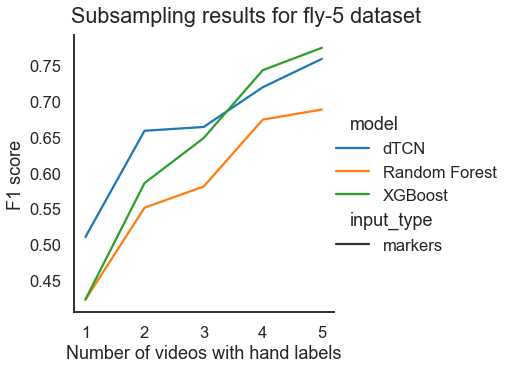

In [20]:
sns.set_context('talk')
sns.set_style('white')

metric = 'f1_dtcn'

data_queried = metrics_df.copy()
# data_queried.loc[data_queried.f1_dtcn.isna(), 'f1_dtcn'] = 0

splt = sns.relplot(
    x='n_labeled_sessions', y=metric, hue='model', style='input_type', ci=None, 
    data=data_queried, kind='line')

# splt = sns.catplot(
#     x='n_labeled_sessions', y=metric, hue='model', ci=95, # style='input_type',
#     data=data_queried, kind='bar')

plt.subplots_adjust(top=0.9)
plt.xlabel('Number of videos with hand labels')
plt.ylabel('F1 score')
splt.fig.suptitle('Subsampling results for %s dataset' % (dataset))
# plt.savefig(
#     '/home/mattw/Dropbox/research-text/posters/2022_cosyne_daart/baselines_%s.pdf' % dataset)
plt.show()

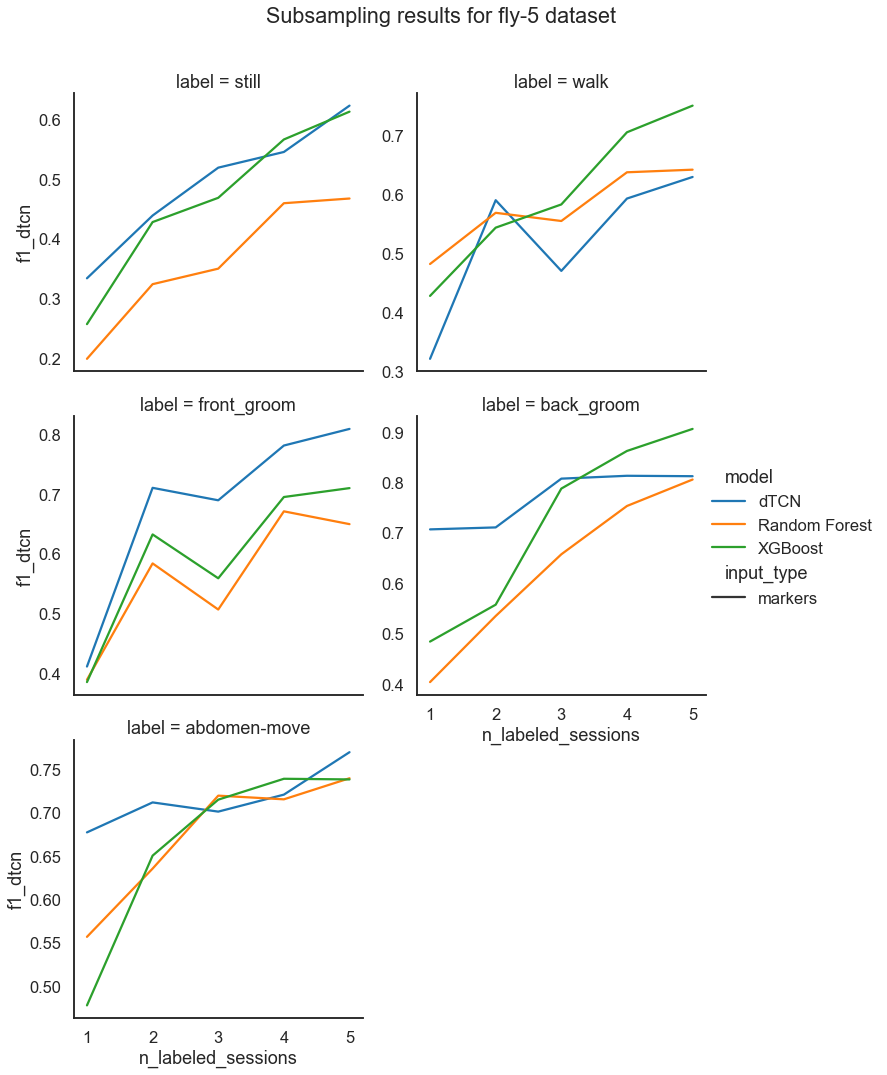

In [21]:
metric = 'f1_dtcn'

data_queried = metrics_df.copy()
data_queried.loc[data_queried.f1_dtcn.isna(), 'f1_dtcn'] = 0

splt = sns.relplot(
    x='n_labeled_sessions', y=metric, hue='model', col='label', col_wrap=2, ci=None,
    data=data_queried, kind='line', style='input_type', facet_kws={'sharey': False, 'sharex': True})

# splt = sns.catplot(
#     x='n_labeled_sessions', y=metric, hue='model', col='label', col_wrap=2, ci=95,
#     data=data_queried, kind='bar', facet_kws={'sharey': False, 'sharex': True})

plt.subplots_adjust(top=0.9)
splt.fig.suptitle('Subsampling results for %s dataset' % (dataset))
plt.show()

In [20]:
# data_queried

In [22]:
n_max_sessions = np.max(data_queried.n_labeled_sessions.unique())
m = data_queried[data_queried.n_labeled_sessions==n_max_sessions].groupby(['model']).mean()
print(m.f1_dtcn)
s = data_queried[data_queried.n_labeled_sessions==n_max_sessions].groupby(['model']).sem()
print(s.f1_dtcn)

model
Random Forest    0.660723
XGBoost          0.743375
dTCN             0.728579
Name: f1_dtcn, dtype: float64
model
Random Forest    0.056583
XGBoost          0.050635
dTCN             0.048323
Name: f1_dtcn, dtype: float64


In [23]:
m = data_queried.groupby(['model', 'n_labeled_sessions', 'sample']).mean().groupby(['model', 'n_labeled_sessions']).mean()
m
# print(m.f1_dtcn)
# s = data_queried[data_queried.n_labeled_sessions==n_max_sessions].groupby(['model']).sem()
# print(s.f1_dtcn)

precision_dtcn  recall_dtcn   f1_dtcn
model         n_labeled_sessions                                       
Random Forest 1                         0.494689     0.476825  0.406001
              2                         0.654744     0.579065  0.529270
              3                         0.717439     0.607103  0.557581
              4                         0.780960     0.692502  0.647194
              5                         0.790868     0.705700  0.660723
XGBoost       1                         0.517254     0.457975  0.406243
              2                         0.665573     0.602719  0.562222
              3                         0.705008     0.661516  0.622504
              4                         0.779223     0.749216  0.713453
              5                         0.805598     0.778954  0.743375
dTCN          1                         0.542856     0.557041  0.489943
              2                         0.697275     0.677099  0.632270
              3                         0.685770     0.684345  0.637378
              4                         0.750847     0.734409  0.690551
              5                         0.800496     0.765780  0.728579

In [24]:
s = data_queried.groupby(['model', 'n_labeled_sessions', 'sample']).mean().groupby(['model', 'n_labeled_sessions']).std()
s

precision_dtcn  recall_dtcn   f1_dtcn
model         n_labeled_sessions                                       
Random Forest 1                         0.077876     0.074249  0.088984
              2                         0.062418     0.069007  0.073653
              3                         0.048242     0.024531  0.023771
              4                         0.029719     0.034201  0.034221
              5                              NaN          NaN       NaN
XGBoost       1                         0.065462     0.050892  0.057377
              2                         0.014756     0.025603  0.027959
              3                         0.025337     0.031405  0.031657
              4                         0.030076     0.033663  0.036078
              5                              NaN          NaN       NaN
dTCN          1                         0.093268     0.043378  0.063780
              2                         0.032076     0.018917  0.023002
              3                         0.028821     0.027531  0.032398
              4                         0.033698     0.027971  0.031648
              5                              NaN          NaN       NaN

In [25]:
timing_dict

{'random-forest': [3095842.716231631,
  3040051.6588146146,
  2804105.1448020176,
  3320129.099577224,
  3062551.8752074344,
  3005200.716495685,
  2957664.246678526,
  3127743.475018643,
  2975019.360662873,
  2878546.54354879,
  2944169.487739898,
  2959466.572587758,
  2930890.4029094605,
  2875586.2756707906,
  2956527.0662116916,
  2909038.0832282472,
  3050755.889111137,
  3071676.170503154,
  2708941.9017702495,
  2912619.1723746094,
  2867231.818534918,
  7908005.35214694,
  7555986.982798698,
  7821075.44474353,
  6864292.260584944,
  7661844.934517759,
  7506475.998037121,
  7908847.128237101,
  7628579.96098391,
  7641132.681995152,
  9116773.524049923,
  7564889.179793748,
  7674620.705937906,
  7626566.405161669,
  6591140.264611953,
  6542470.5453173155,
  7472395.850693946,
  6713918.492222294,
  7305918.076080238,
  7681875.457875458,
  6505562.454656893,
  7212404.4320561355,
  4248890.439676398,
  4936007.714813422,
  4620761.808583888,
  4310077.469814175,
  3818982.

In [28]:
a = timing_dict['xgboost']
print(np.mean(a))
print(np.std(a))

6382161.289473731
2287977.2339264452


### plot results: heat plots for single model

In [ ]:
# sns.set_context('talk')
# sns.set_style('white')

# metric = 'f1_dtcn'

# n_rows = 2
# n_cols = 2

# # 1: by dataset/label
# # 2: by label, avg over datasets
# # 3: avg over dataset/label
# plot_types = [2, 3]

# for plot_type in plot_types:
#     annot = True #True if plot_type == 3 else False
#     plot_heatmaps(
#         df=metrics_df, metric=metric, sess_ids=sess_ids_test, 
#         title=metric.split('_')[-1].upper(), kind=plot_type, vmin=0.7, vmax=1,
#         annot=annot, 
#         cmaps=['Oranges_r', 'Greens_r', 'Reds_r', 'Purples_r', 'Blues_r', 'Greys_r'],
#         save_file=None)
